# FaceSense AI — Data Pipeline Exploration

> **FER2013 Facial Expression Recognition | Portfolio Project**

This notebook explores the complete FER2013 data pipeline from raw images to model-ready tensors.
It serves as a reference for understanding dataset characteristics, class imbalance, and how the
pipeline prepares data for training.

---
**Sections:**
1. Project Overview
2. Dataset Statistics
3. Class Distribution
4. Sample Images
5. Image Properties
6. Train / Validation Split
7. Data Augmentation
8. Class Imbalance Handling
9. PyTorch Dataset and DataLoader
10. Final Data Pipeline
11. Final Summary

In [1]:
# ── Environment Setup ─────────────────────────────────────────────────────────
import sys
from pathlib import Path

# Ensure project root is always on sys.path regardless of where Jupyter is launched
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import torch

# Matplotlib style
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"Project root : {PROJECT_ROOT}")
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")

Project root : C:\Users\moham\OneDrive\Desktop\AI projects\AI Emotion Detection
Python       : 3.11.9
PyTorch      : 2.14.0+cpu


---
## 1 · Project Overview

In [2]:
from ml.data.dataloader import load_yaml_config

config = load_yaml_config(PROJECT_ROOT / "configs" / "config.yaml")

print("=" * 60)
print(f"  Project   : {config['project']['name']}")
print(f"  Dataset   : {config['dataset']['name']}")
print(f"  Image size: {config['dataset']['image_size']} px  |  {config['dataset']['channels']} channel (grayscale)")
print(f"  Classes   : {config['classes']['num_classes']}")
print(f"  Seed      : {config['project']['seed']}")
print("=" * 60)
print("\nEmotion classes:")
for name, idx in config['classes']['mapping'].items():
    print(f"  [{idx}] {name}")

  Project   : FaceSense AI
  Dataset   : FER2013
  Image size: [48, 48] px  |  1 channel (grayscale)
  Classes   : 7
  Seed      : 42

Emotion classes:
  [0] angry
  [1] disgust
  [2] fear
  [3] happy
  [4] neutral
  [5] sad
  [6] surprise


### FER2013 Dataset Structure

The **FER2013** dataset contains **35,887** grayscale face images at **48×48 pixels**, pre-organised into two splits:

```
Data(FER2013)/
├── train/          # 28,709 images  (~80%)
│   ├── angry/
│   ├── disgust/    # ⚠ severely under-represented (~1.5%)
│   ├── fear/
│   ├── happy/      # most represented class
│   ├── neutral/
│   ├── sad/
│   └── surprise/
└── test/           # 7,178 images   (~20%)
    └── ...
```

Each class folder contains `.jpg` images collected from internet search results and annotated via Amazon Mechanical Turk.

---
## 2 · Dataset Statistics

In [3]:
import os

train_dir = PROJECT_ROOT / config['dataset']['train_split_dir']
test_dir  = PROJECT_ROOT / config['dataset']['test_split_dir']
class_names = config['classes']['names']

def count_class_images(split_dir: Path) -> dict:
    """Count images per class in a split directory."""
    counts = {}
    for cls in class_names:
        folder = split_dir / cls
        counts[cls] = len(list(folder.glob("*.jpg"))) if folder.exists() else 0
    return counts

train_counts = count_class_images(train_dir)
test_counts  = count_class_images(test_dir)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())
total        = total_train + total_test

print(f"{'Emotion':<12} {'Train':>8} {'Test':>7} {'Total':>8} {'Train %':>9}")
print("-" * 50)
for cls in class_names:
    tr = train_counts[cls]
    te = test_counts[cls]
    print(f"{cls:<12} {tr:>8,} {te:>7,} {tr+te:>8,} {100*tr/total_train:>8.1f}%")
print("-" * 50)
print(f"{'TOTAL':<12} {total_train:>8,} {total_test:>7,} {total:>8,} {'100.0%':>9}")
print(f"\nImage size : {config['dataset']['image_size'][0]} × {config['dataset']['image_size'][1]} px")
print(f"Channels   : {config['dataset']['channels']} (grayscale)")

Emotion         Train    Test    Total   Train %
--------------------------------------------------
angry           3,995     958    4,953     13.9%
disgust           436     111      547      1.5%
fear            4,097   1,024    5,121     14.3%
happy           7,215   1,774    8,989     25.1%
neutral         4,965   1,233    6,198     17.3%
sad             4,830   1,247    6,077     16.8%
surprise        3,171     831    4,002     11.0%
--------------------------------------------------
TOTAL          28,709   7,178   35,887    100.0%

Image size : 48 × 48 px
Channels   : 1 (grayscale)


---
## 3 · Class Distribution

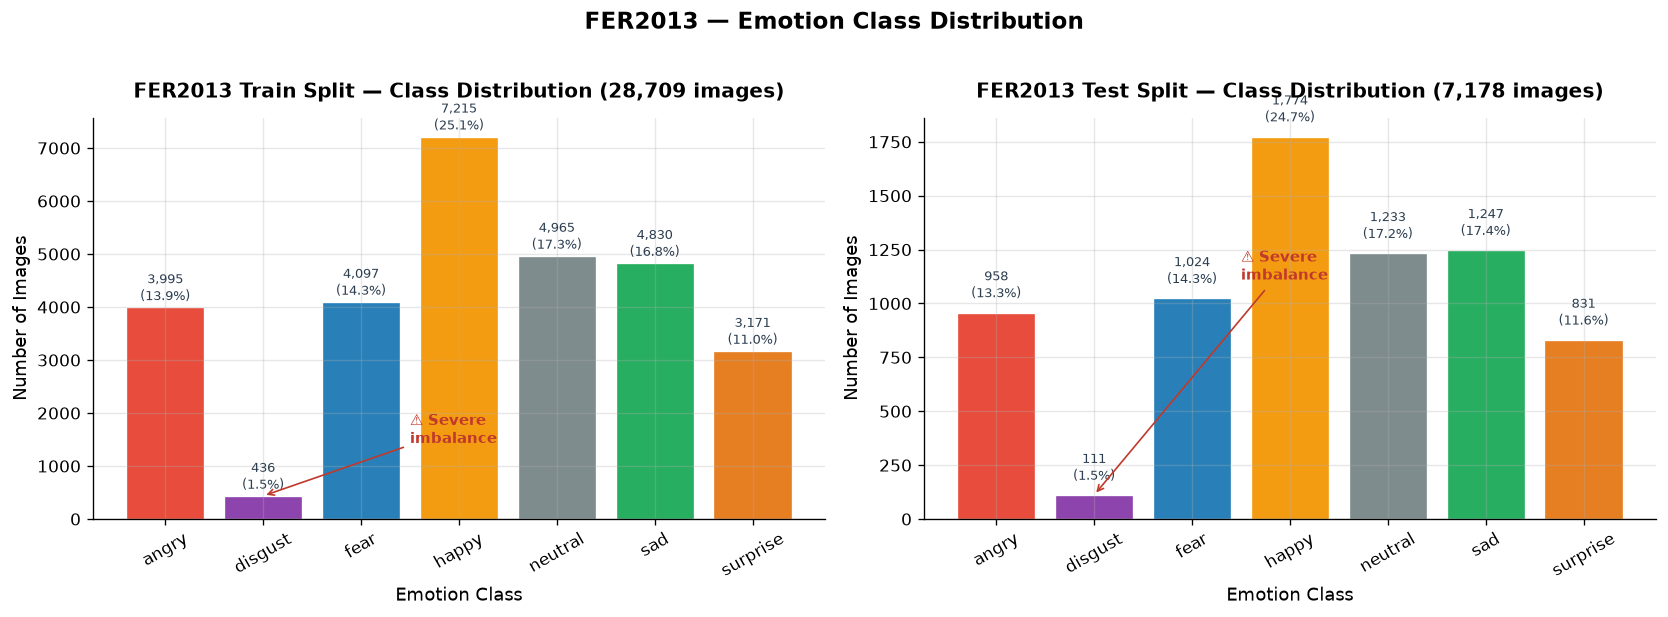


Class imbalance ratio (happy / disgust): 16.5×


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#e74c3c","#8e44ad","#2980b9","#f39c12","#7f8c8d","#27ae60","#e67e22"]

for ax, (split_counts, split_name, total_n) in zip(
    axes,
    [(train_counts, "Train", total_train), (test_counts, "Test", total_test)]
):
    bars = ax.bar(class_names, [split_counts[c] for c in class_names],
                  color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"FER2013 {split_name} Split — Class Distribution ({total_n:,} images)",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Emotion Class", fontsize=11)
    ax.set_ylabel("Number of Images", fontsize=11)
    ax.tick_params(axis="x", rotation=30)

    # Annotate bars
    for bar, cls in zip(bars, class_names):
        count = split_counts[cls]
        pct   = 100 * count / total_n
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f"{count:,}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=8, color="#2c3e50")

    # Highlight disgust
    ax.annotate("⚠ Severe\nimbalance", xy=(1, split_counts["disgust"]),
                xytext=(2.5, split_counts["disgust"] + 1000),
                arrowprops=dict(arrowstyle="->", color="#c0392b"),
                fontsize=9, color="#c0392b", fontweight="bold")

plt.suptitle("FER2013 — Emotion Class Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio (happy / disgust): "
      f"{train_counts['happy'] / train_counts['disgust']:.1f}×")

---
## 4 · Sample Images

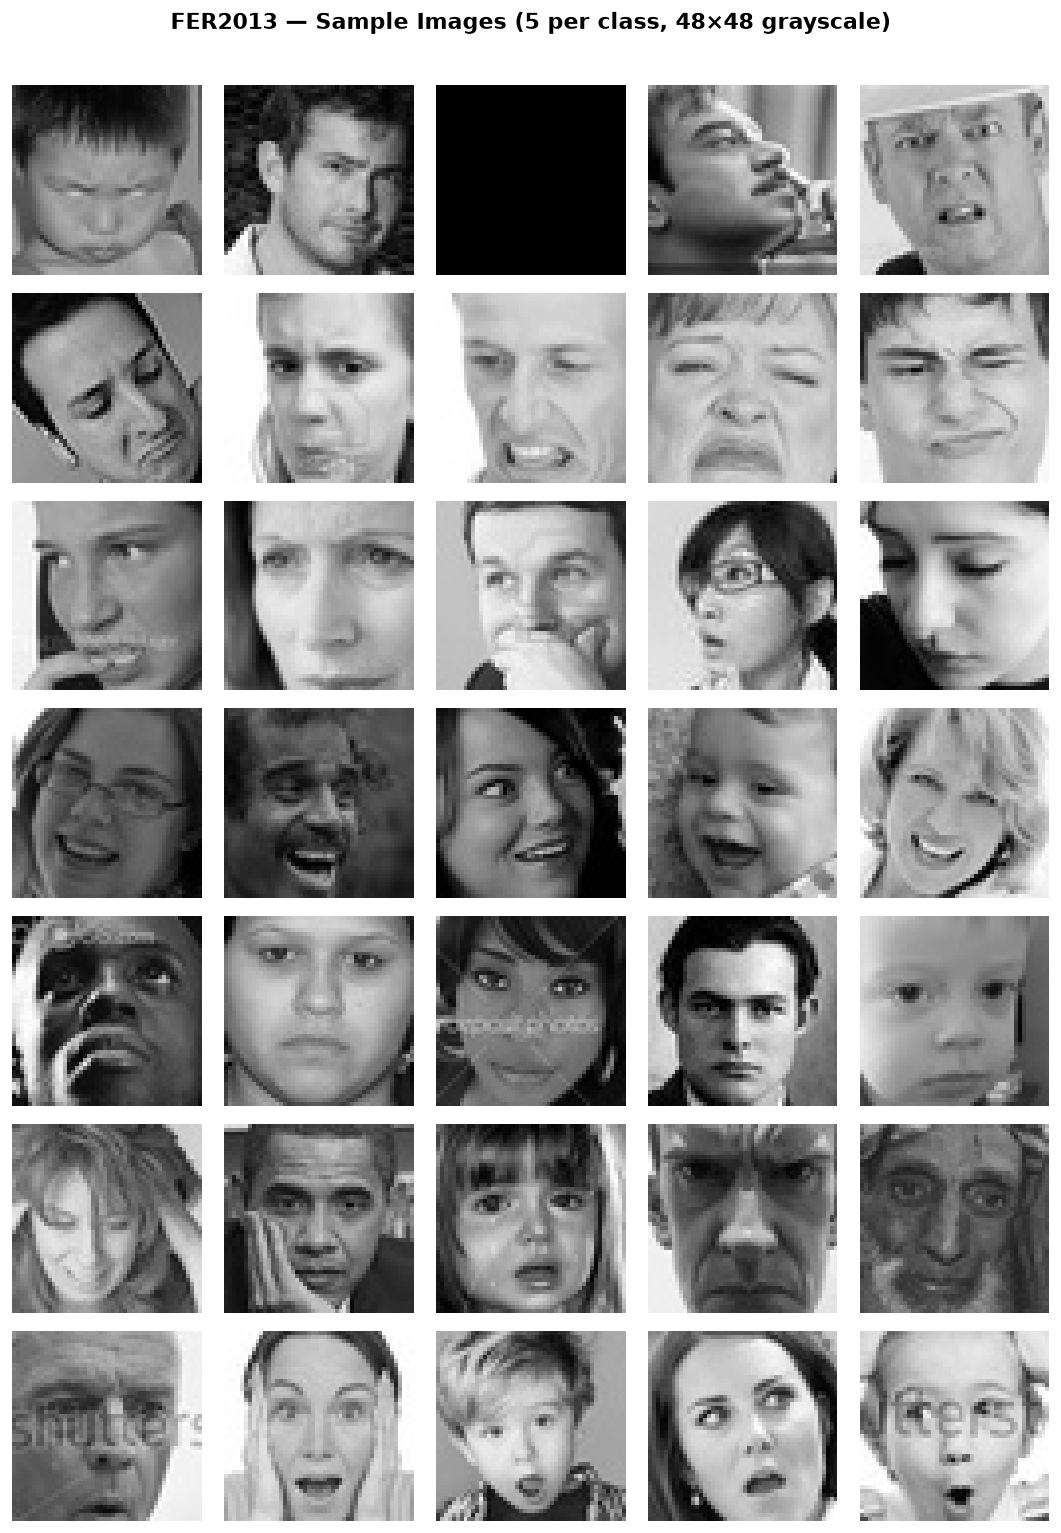

In [5]:
def get_sample_paths(split_dir: Path, cls: str, n: int = 5) -> list:
    """Return up to n image paths for a given class."""
    folder = split_dir / cls
    return sorted(folder.glob("*.jpg"))[:n]

n_samples = 5
fig, axes = plt.subplots(len(class_names), n_samples,
                          figsize=(n_samples * 1.8, len(class_names) * 1.8))

for row_idx, cls in enumerate(class_names):
    paths = get_sample_paths(train_dir, cls, n_samples)
    for col_idx in range(n_samples):
        ax = axes[row_idx][col_idx]
        if col_idx < len(paths):
            img = Image.open(paths[col_idx]).convert("L")
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            ax.set_facecolor("#f0f0f0")
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(cls.capitalize(), fontsize=10,
                          fontweight="bold", rotation=0,
                          labelpad=50, va="center")

fig.suptitle("FER2013 — Sample Images (5 per class, 48×48 grayscale)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 5 · Image Properties

In [6]:
# Verify a sample from each class
print(f"{'Class':<12} {'Mode':<8} {'Size':<14} {'Min':>6} {'Max':>6} {'Mean':>8} {'Std':>8}")
print("-" * 64)

sample_arrays = {}   # for histogram
for cls in class_names:
    path = get_sample_paths(train_dir, cls, 1)[0]
    img  = Image.open(path).convert("L")
    arr  = np.array(img)
    sample_arrays[cls] = arr
    print(f"{cls:<12} {img.mode:<8} {str(img.size):<14} "
          f"{arr.min():>6} {arr.max():>6} {arr.mean():>8.1f} {arr.std():>8.1f}")

Class        Mode     Size              Min    Max     Mean      Std
----------------------------------------------------------------
angry        L        (48, 48)            3    197    106.0     51.1
disgust      L        (48, 48)            0    217    114.6     52.8


fear         L        (48, 48)           12    255    137.1     53.7
happy        L        (48, 48)            0    255     79.0     39.8
neutral      L        (48, 48)            2    254     88.9     61.1
sad          L        (48, 48)           18    231    127.1     51.1


surprise     L        (48, 48)            8    255    135.1     54.5


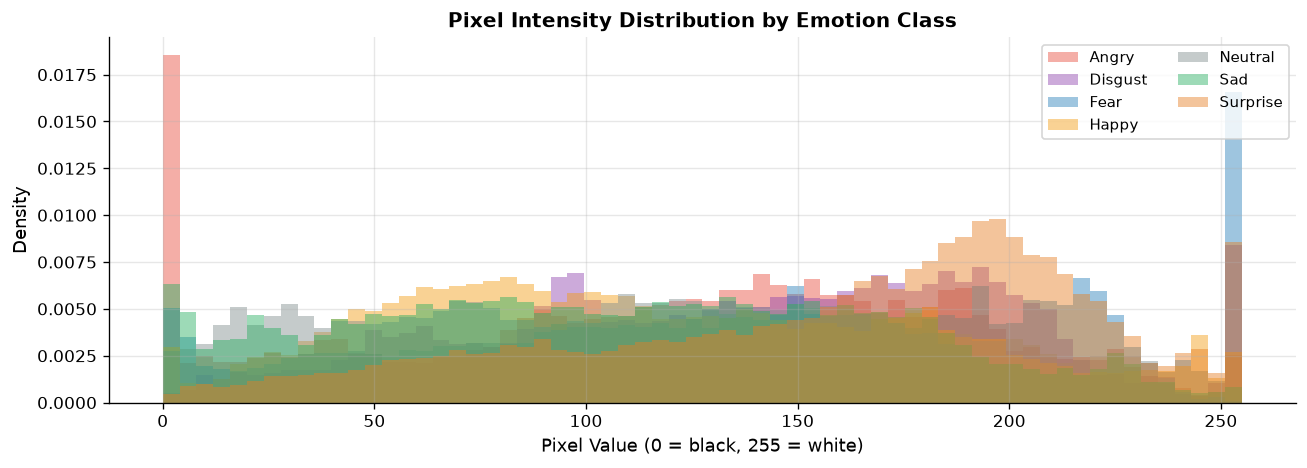


All images confirmed: 48×48 px, single-channel grayscale (mode='L')


In [7]:
# Pixel-value histogram — pool ~100 images from each class
fig, ax = plt.subplots(figsize=(11, 4))

for cls, color in zip(class_names, colors):
    paths = get_sample_paths(train_dir, cls, 15)
    pixel_vals = np.concatenate([np.array(Image.open(p).convert("L")).ravel() for p in paths])
    ax.hist(pixel_vals, bins=64, range=(0, 255), alpha=0.45,
            color=color, label=cls.capitalize(), density=True)

ax.set_title("Pixel Intensity Distribution by Emotion Class",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Pixel Value (0 = black, 255 = white)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

print("\nAll images confirmed: 48×48 px, single-channel grayscale (mode='L')")

---
## 6 · Train / Validation Split

The pipeline splits the **original train folder** (85% / 15%) using a **reproducible stratified split** via `sklearn.model_selection.train_test_split`. This preserves the original class proportions in both subsets.

In [8]:
from ml.data.dataset import create_train_val_split

val_ratio     = config['dataset']['val_split_ratio']
class_mapping = config['classes']['mapping']
seed          = config['dataset']['seed']

train_samples, val_samples = create_train_val_split(
    train_dir=train_dir,
    class_mapping=class_mapping,
    val_ratio=val_ratio,
    seed=seed,
)

# Count per class
def samples_to_class_counts(samples, class_names):
    counts = {c: 0 for c in class_names}
    for _, label in samples:
        counts[class_names[label]] += 1
    return counts

tr_split_counts  = samples_to_class_counts(train_samples, class_names)
val_split_counts = samples_to_class_counts(val_samples, class_names)

print(f"Total training  samples : {len(train_samples):,} ({100*(1-val_ratio):.0f}%)")
print(f"Total validation samples: {len(val_samples):,}   ({100*val_ratio:.0f}%)")
print(f"\n{'Class':<12} {'Train':>8} {'Val':>8} {'Val %':>8}")
print("-" * 42)
for cls in class_names:
    tr = tr_split_counts[cls]
    vl = val_split_counts[cls]
    print(f"{cls:<12} {tr:>8,} {vl:>8,} {100*vl/(tr+vl):>7.1f}%")

Total training  samples : 24,402 (85%)
Total validation samples: 4,307   (15%)

Class           Train      Val    Val %
------------------------------------------
angry           3,396      599    15.0%
disgust           371       65    14.9%
fear            3,482      615    15.0%
happy           6,133    1,082    15.0%
neutral         4,220      745    15.0%
sad             4,105      725    15.0%
surprise        2,695      476    15.0%


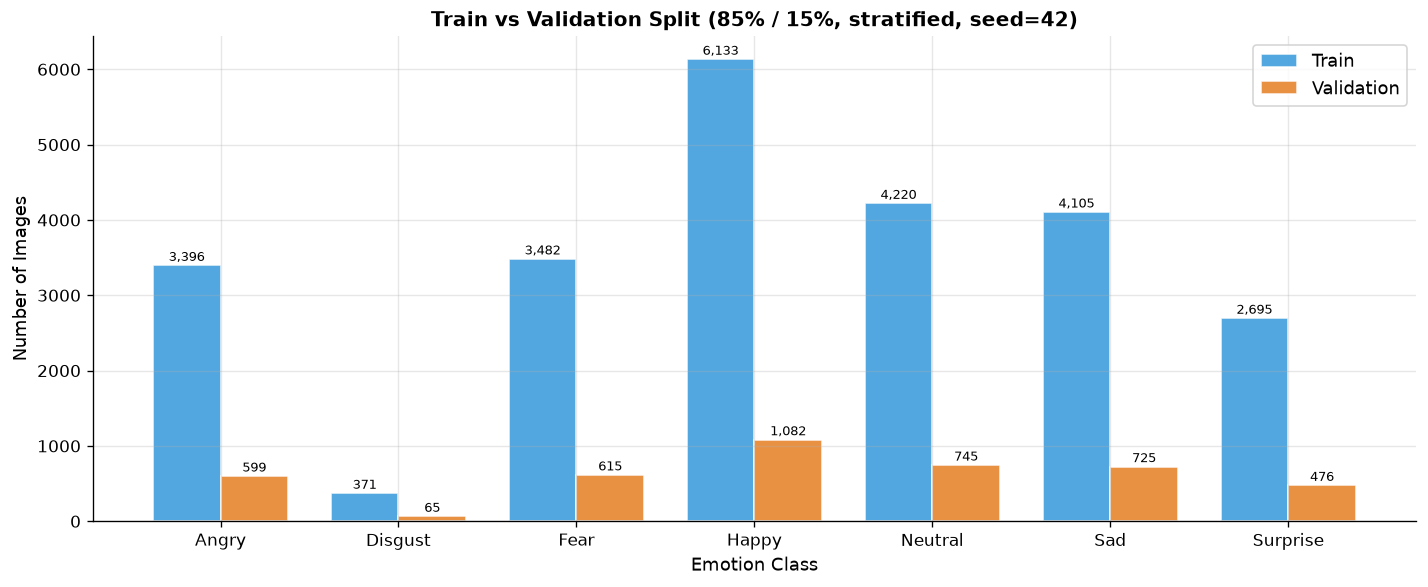

In [9]:
x       = np.arange(len(class_names))
width   = 0.38
fig, ax = plt.subplots(figsize=(12, 5))

bars_tr  = ax.bar(x - width/2, [tr_split_counts[c]  for c in class_names],
                  width, label="Train",      color="#3498db", alpha=0.85, edgecolor="white")
bars_val = ax.bar(x + width/2, [val_split_counts[c] for c in class_names],
                  width, label="Validation", color="#e67e22", alpha=0.85, edgecolor="white")

ax.set_title(f"Train vs Validation Split (85% / 15%, stratified, seed={seed})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Emotion Class", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in class_names])
ax.legend(fontsize=11)

for bar in list(bars_tr) + list(bars_val):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

---
## 7 · Data Augmentation

Training images pass through a stochastic augmentation pipeline to improve generalisation:

| Transform | Purpose |
|---|---|
| `RandomResizedCrop(48×48, scale=0.85–1.0)` | Controlled zoom; preserves facial landmarks |
| `RandomHorizontalFlip(p=0.5)` | Accounts for mirror symmetry of faces |
| `RandomRotation(±10°)` | Handles slight head tilt |
| `Normalize(mean=0.5, std=0.5)` | Maps [0,1] → [−1, 1]; stabilises training |

In [10]:
from ml.data.dataloader import get_transforms

aug_cfg        = config.get("augmentation", {})
img_size       = tuple(config['dataset']['image_size'])
train_transform = get_transforms(
    img_size=img_size,
    is_train=True,
    hflip_prob=aug_cfg.get("horizontal_flip_prob", 0.5),
    rotation_deg=aug_cfg.get("rotation_degrees", 10),
    crop_scale=tuple(aug_cfg.get("crop_scale", [0.85, 1.0])),
)
eval_transform = get_transforms(img_size=img_size, is_train=False)

print("Training augmentation pipeline:")
for i, t in enumerate(train_transform.transforms):
    print(f"  {i+1}. {t}")

print("\nValidation / Test pipeline:")
for i, t in enumerate(eval_transform.transforms):
    print(f"  {i+1}. {t}")

Training augmentation pipeline:
  1. RandomResizedCrop(size=(48, 48), scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
  2. RandomHorizontalFlip(p=0.5)
  3. RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
  4. ToTensor()
  5. Normalize(mean=[0.5], std=[0.5])

Validation / Test pipeline:
  1. Resize(size=(48, 48), interpolation=bilinear, max_size=None, antialias=True)
  2. ToTensor()
  3. Normalize(mean=[0.5], std=[0.5])


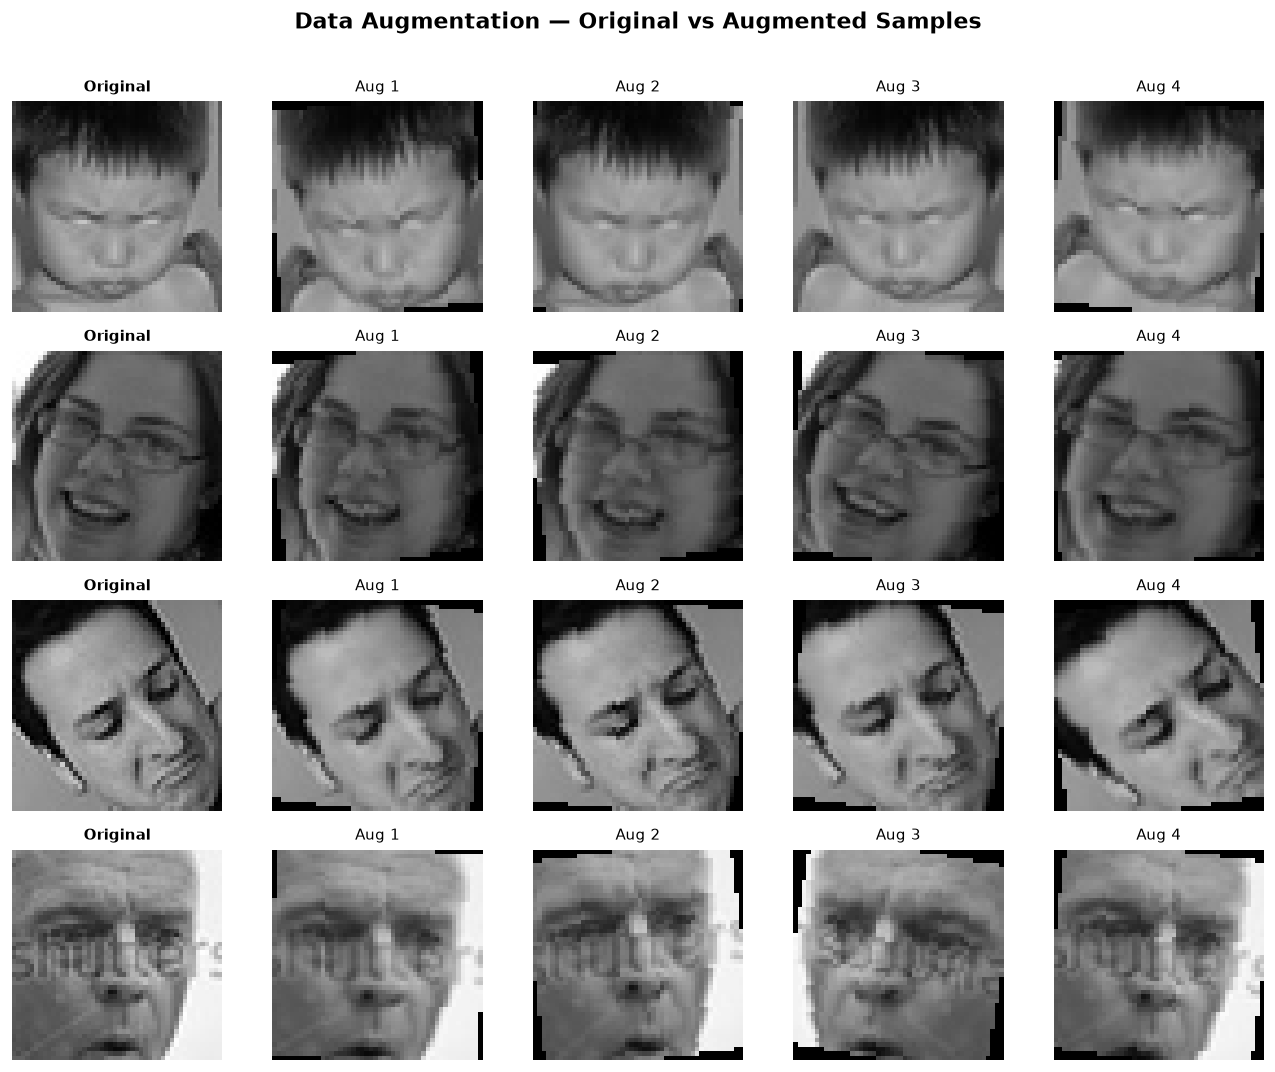

In [11]:
def tensor_to_display(t: torch.Tensor) -> np.ndarray:
    """Convert a normalised [−1,1] grayscale tensor to uint8 for display."""
    arr = t.squeeze(0).numpy()           # (H, W)
    arr = (arr * 0.5 + 0.5) * 255.0     # undo Normalize(0.5, 0.5)
    return np.clip(arr, 0, 255).astype(np.uint8)

torch.manual_seed(seed)
n_aug_examples = 4
selected_classes = ["angry", "happy", "disgust", "surprise"]

fig, axes = plt.subplots(len(selected_classes), n_aug_examples + 1,
                          figsize=((n_aug_examples + 1) * 2.2, len(selected_classes) * 2.2))

for row, cls in enumerate(selected_classes):
    path = get_sample_paths(train_dir, cls, 1)[0]
    pil_img = Image.open(path).convert("L")

    # Column 0 — original
    axes[row][0].imshow(np.array(pil_img), cmap="gray", vmin=0, vmax=255)
    axes[row][0].set_title("Original", fontsize=9, fontweight="bold")
    axes[row][0].set_ylabel(cls.capitalize(), fontsize=10, fontweight="bold",
                             rotation=0, labelpad=55, va="center")
    axes[row][0].axis("off")

    # Columns 1–n_aug_examples — augmented versions
    for col in range(1, n_aug_examples + 1):
        aug_tensor = train_transform(pil_img)
        axes[row][col].imshow(tensor_to_display(aug_tensor), cmap="gray", vmin=0, vmax=255)
        axes[row][col].set_title(f"Aug {col}", fontsize=9)
        axes[row][col].axis("off")

fig.suptitle("Data Augmentation — Original vs Augmented Samples",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 8 · Class Imbalance Handling

The FER2013 dataset has a **severe class imbalance**: the `disgust` class contains only ~1.5% of training samples, while `happy` contains ~25%. Training with uniform sampling would cause the model to ignore rare classes.

**Strategy: `WeightedRandomSampler`**  
Each sample is assigned a weight inversely proportional to its class frequency. During training, the sampler draws batches where each class appears roughly equally, without modifying or duplicating the original images.

In [12]:
from ml.data.dataloader import create_weighted_sampler, compute_class_weights
from ml.data.dataset import FER2013Dataset

# Build raw training dataset (no transform needed — we just need labels)
train_dataset_raw = FER2013Dataset(
    samples=train_samples,
    class_names=class_names,
    transform=None,
)
train_labels = train_dataset_raw.get_labels()

# Class weights computed by the pipeline
class_weights = compute_class_weights(train_labels, num_classes=len(class_names), mode="balanced")
print("Class weights (balanced mode):")
for cls, w in zip(class_names, class_weights):
    print(f"  {cls:<12} weight = {w:.4f}")

Class weights (balanced mode):
  angry        weight = 1.0265
  disgust      weight = 9.3962
  fear         weight = 1.0011
  happy        weight = 0.5684
  neutral      weight = 0.8261
  sad          weight = 0.8492
  surprise     weight = 1.2935


In [13]:
from torch.utils.data import DataLoader

# Create sampler and draw ONE full epoch's worth of batches to measure effective distribution
sampler     = create_weighted_sampler(train_labels, num_classes=len(class_names))
sample_loader = DataLoader(
    train_dataset_raw,
    batch_size=64,
    sampler=sampler,
    num_workers=0,
)

# Count sampled labels over one full epoch
sampled_counts = {c: 0 for c in class_names}
for _, labels in sample_loader:
    for lbl in labels.tolist():
        sampled_counts[class_names[lbl]] += 1

total_sampled = sum(sampled_counts.values())
print(f"Sampled {total_sampled:,} labels over one epoch")

Sampled 24,402 labels over one epoch


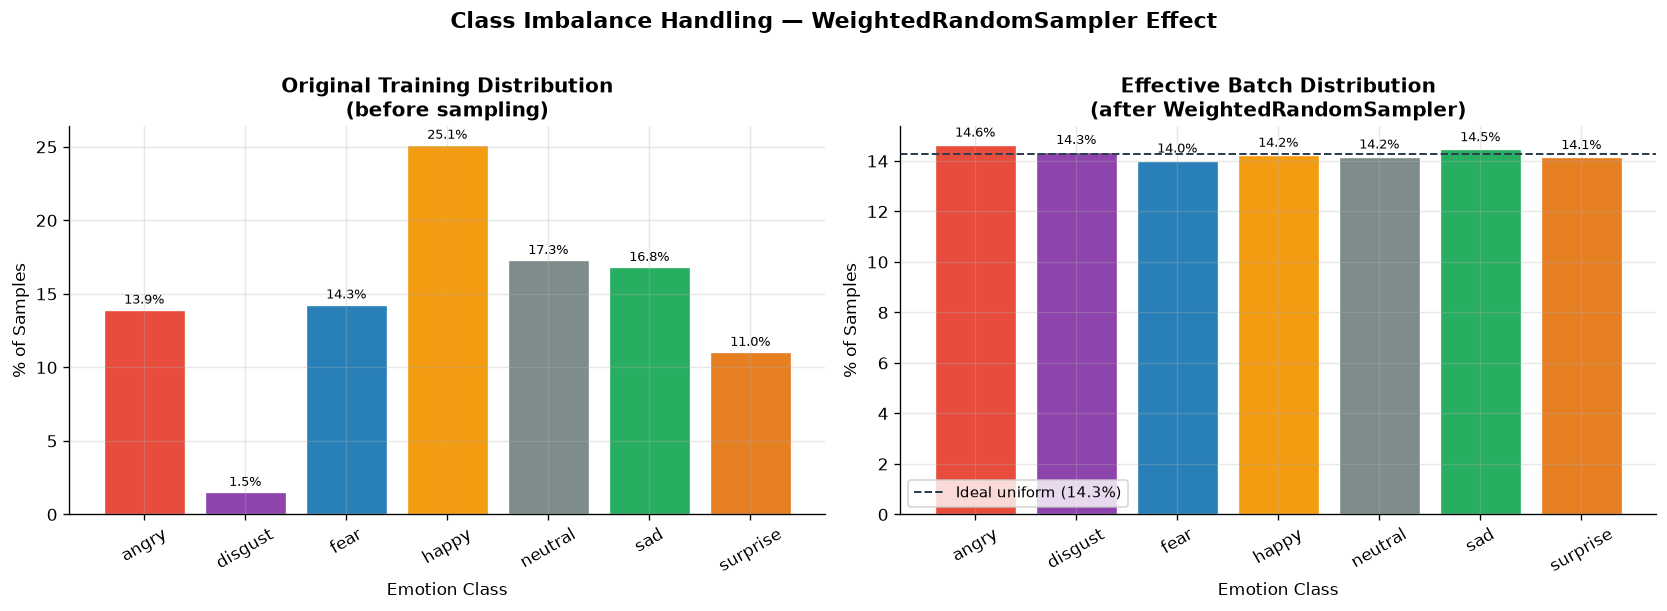

In [14]:
x     = np.arange(len(class_names))
width = 0.38
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw original distribution
orig_vals    = [tr_split_counts[c] for c in class_names]
orig_total   = sum(orig_vals)
orig_pcts    = [100 * v / orig_total for v in orig_vals]
bars_orig    = axes[0].bar(class_names, orig_pcts, color=colors,
                           edgecolor="white", linewidth=0.8)
axes[0].set_title("Original Training Distribution\n(before sampling)",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Emotion Class")
axes[0].set_ylabel("% of Samples")
axes[0].tick_params(axis="x", rotation=30)
for bar, pct in zip(bars_orig, orig_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

# Right: sampled distribution (after WeightedRandomSampler)
samp_vals = [sampled_counts[c] for c in class_names]
samp_total = sum(samp_vals)
samp_pcts  = [100 * v / samp_total for v in samp_vals]
bars_samp  = axes[1].bar(class_names, samp_pcts, color=colors,
                          edgecolor="white", linewidth=0.8)
axes[1].set_title("Effective Batch Distribution\n(after WeightedRandomSampler)",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Emotion Class")
axes[1].set_ylabel("% of Samples")
axes[1].tick_params(axis="x", rotation=30)
ideal_pct = 100 / len(class_names)
axes[1].axhline(ideal_pct, color="#2c3e50", linestyle="--", linewidth=1.2,
                 label=f"Ideal uniform ({ideal_pct:.1f}%)")
axes[1].legend(fontsize=9)
for bar, pct in zip(bars_samp, samp_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

fig.suptitle("Class Imbalance Handling — WeightedRandomSampler Effect",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 9 · PyTorch Dataset and DataLoader

In [15]:
from ml.data.dataloader import build_dataloaders

# Build the full production DataLoaders from config
train_loader, val_loader, test_loader, metadata = build_dataloaders(config)

print("DataLoader summary")
print("=" * 45)
print(f"  Train batches : {len(train_loader):,}  ({metadata['train_count']:,} samples)")
print(f"  Val batches   : {len(val_loader):,}    ({metadata['val_count']:,} samples)")
print(f"  Test batches  : {len(test_loader):,}   ({metadata['test_count']:,} samples)")
print(f"  Batch size    : {config['dataloader']['batch_size']}")
print(f"  num_workers   : {config['dataloader']['num_workers']}")
print(f"  pin_memory    : {config['dataloader']['pin_memory']}")

DataLoader summary
  Train batches : 382  (24,402 samples)
  Val batches   : 68    (4,307 samples)
  Test batches  : 113   (7,178 samples)
  Batch size    : 64
  num_workers   : 4
  pin_memory    : False


In [16]:
# Inspect one batch
images, labels = next(iter(train_loader))

print("One training batch:")
print(f"  images.shape : {tuple(images.shape)}   [batch, channels, H, W]")
print(f"  labels.shape : {tuple(labels.shape)}")
print(f"  images.dtype : {images.dtype}")
print(f"  images range : [{images.min():.3f},  {images.max():.3f}]  (normalised)")
print(f"  labels dtype : {labels.dtype}")
print(f"  Unique labels in batch: {sorted(labels.unique().tolist())}")

# Class distribution in this single batch
batch_dist = {c: 0 for c in class_names}
for lbl in labels.tolist():
    batch_dist[class_names[lbl]] += 1
print(f"\n  Batch class breakdown:")
for cls, cnt in batch_dist.items():
    print(f"    {cls:<12} {cnt:>3}")

One training batch:
  images.shape : (64, 1, 48, 48)   [batch, channels, H, W]
  labels.shape : (64,)
  images.dtype : torch.float32
  images range : [-1.000,  1.000]  (normalised)
  labels dtype : torch.int64
  Unique labels in batch: [0, 1, 2, 3, 4, 5, 6]

  Batch class breakdown:
    angry          7
    disgust        6
    fear          10
    happy          5
    neutral        9
    sad           17
    surprise      10


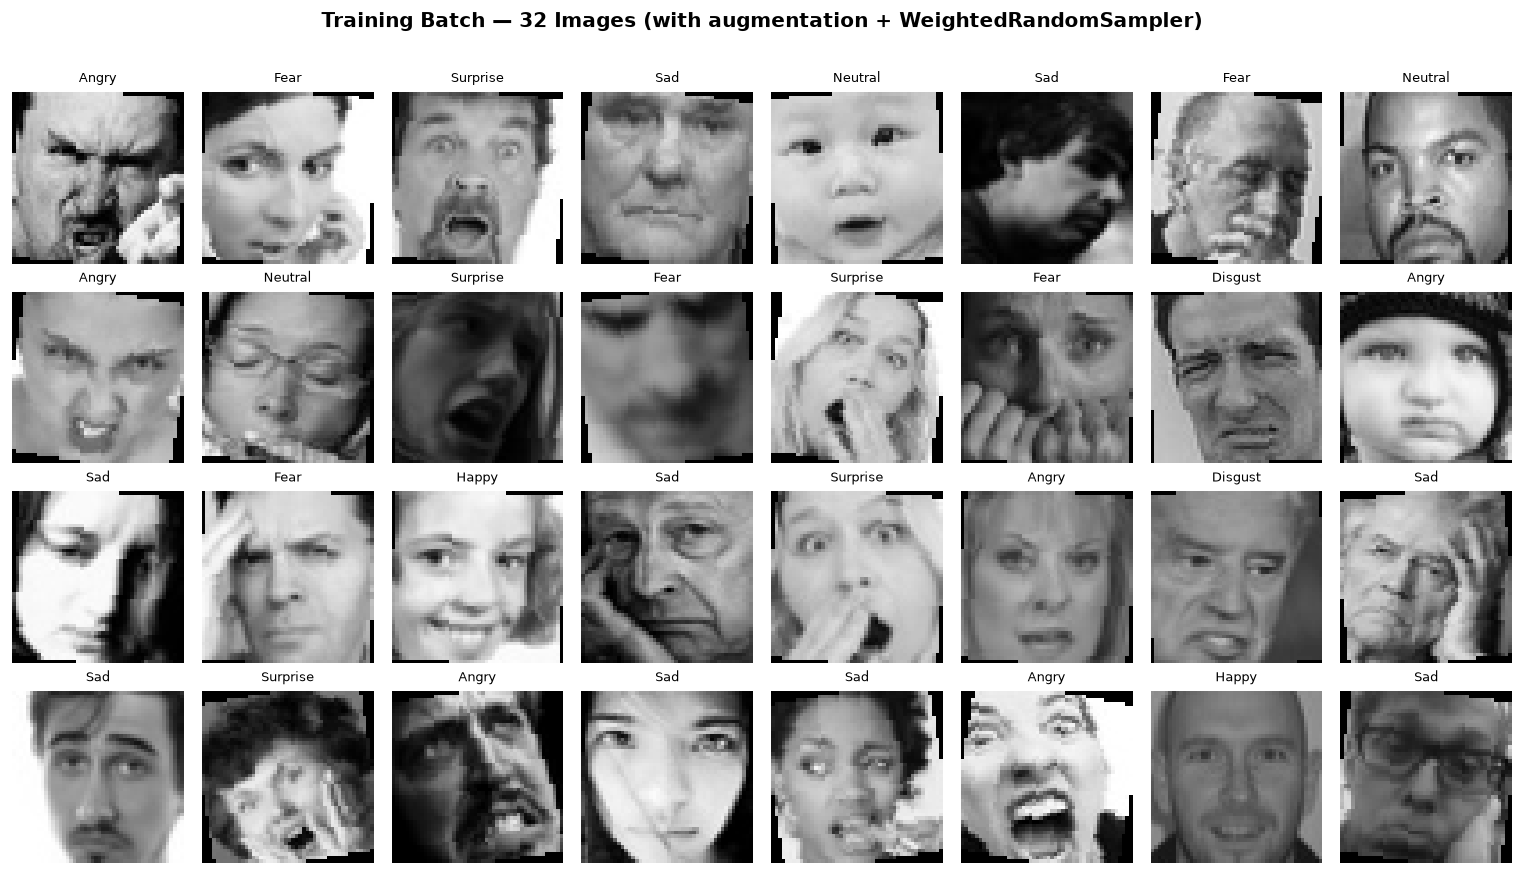

In [17]:
# Visualise a grid of images from the batch
n_show = 32
ncols  = 8
nrows  = n_show // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.6, nrows * 1.8))

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue
    img_arr = tensor_to_display(images[i])
    lbl_name = class_names[labels[i].item()].capitalize()
    ax.imshow(img_arr, cmap="gray", vmin=0, vmax=255)
    ax.set_title(lbl_name, fontsize=8)
    ax.axis("off")

fig.suptitle(f"Training Batch — {n_show} Images (with augmentation + WeightedRandomSampler)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 10 · Final Data Pipeline

The following diagram shows the complete data flow from raw images to model-ready tensors:

```
┌─────────────────────────────────────────────────────────────────────────┐
│                       FaceSense AI — Data Pipeline                      │
└─────────────────────────────────────────────────────────────────────────┘

  Data(FER2013)/train/         Data(FER2013)/test/
  [28,709 × 48×48 JPEGs]       [7,178 × 48×48 JPEGs]
          │                              │
          ▼                              │
  ┌───────────────────┐                  │
  │ Stratified Split  │                  │
  │  85% / 15%        │                  │
  │  seed = 42        │                  │
  └─────────┬─────────┘                  │
            │                            │
     ┌──────┴──────┐               ┌─────┘
     ▼             ▼               ▼
 Train Set      Val Set        Test Set
 (24,402)       (4,307)        (7,178)
     │             │               │
     ▼             ▼               ▼
 Augmentation   Resize          Resize
 RandomCrop     ToTensor        ToTensor
 HFlip          Normalize       Normalize
 Rotation
 ToTensor
 Normalize
     │             │               │
     ▼             │               │
 WeightedRandom    │               │
 Sampler           │               │
 (balances         │               │
  class dist.)     │               │
     │             │               │
     ▼             ▼               ▼
 DataLoader     DataLoader     DataLoader
 batch=64       batch=64       batch=64
 workers=4      workers=4      workers=4
     │             │               │
     └──────┬──────┘               │
            ▼                      ▼
     Tensor [64, 1, 48, 48]  Tensor [64, 1, 48, 48]
     range: [−1, 1]          range: [−1, 1]
            │                      │
            ▼                      ▼
       BaselineEmotionCNN → Final Test Evaluation
```

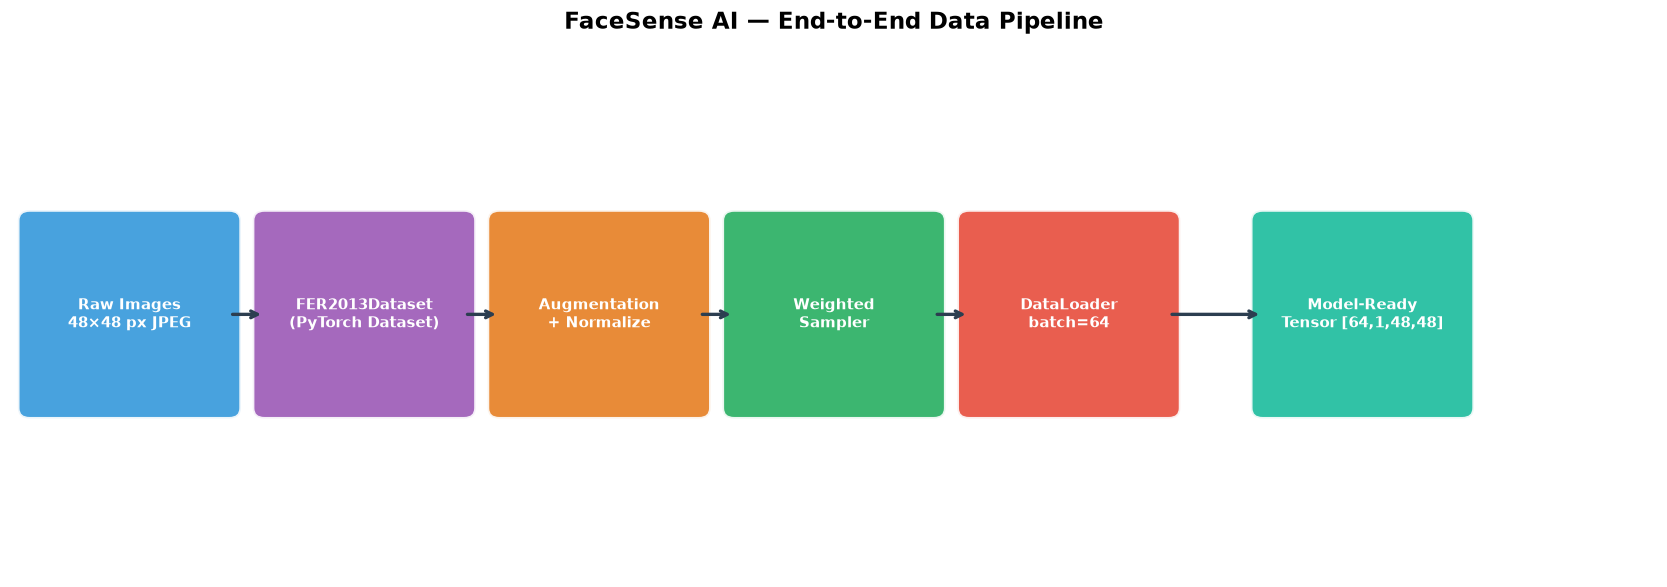

In [18]:
# Visual pipeline schematic using matplotlib patches
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")

stage_colors = ["#3498db", "#9b59b6", "#e67e22", "#27ae60", "#e74c3c", "#1abc9c"]
stages = [
    ("Raw Images\n48×48 px JPEG", 1.0),
    ("FER2013Dataset\n(PyTorch Dataset)", 3.0),
    ("Augmentation\n+ Normalize", 5.0),
    ("Weighted\nSampler", 7.0),
    ("DataLoader\nbatch=64", 9.0),
    ("Model-Ready\nTensor [64,1,48,48]", 11.5),
]

for (label, x), color in zip(stages, stage_colors):
    box = FancyBboxPatch((x - 0.85, 1.6), 1.7, 1.8,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor="white",
                          linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, 2.5, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white",
            wrap=True)

# Arrows between stages
for i in range(len(stages) - 1):
    x_start = stages[i][1] + 0.85
    x_end   = stages[i+1][1] - 0.85
    ax.annotate("", xy=(x_end, 2.5), xytext=(x_start, 2.5),
                arrowprops=dict(arrowstyle="->", color="#2c3e50",
                                lw=2.0, connectionstyle="arc3,rad=0"))

ax.set_title("FaceSense AI — End-to-End Data Pipeline",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

---
## 11 · Final Summary

### Dataset Characteristics

| Property | Value |
|---|---|
| Dataset | FER2013 |
| Total images | 35,887 |
| Image size | 48 × 48 px |
| Channels | 1 (grayscale) |
| Emotion classes | 7 (angry, disgust, fear, happy, neutral, sad, surprise) |
| Pre-split | train (28,709) / test (7,178) |
| Val split | 15% of train, stratified (seed=42) → 4,307 images |

---

### Class Imbalance

FER2013 suffers from **severe class imbalance**. The `disgust` class contains only ~1.5% of training images (~436 images), while `happy` contains ~25% (~7,215 images) — a **~16× ratio**. Without mitigation, a naive model learns to predict frequent classes and ignores `disgust` and `fear`.

---

### How the Pipeline Prepares Data for Training

| Step | What it does | Why |
|---|---|---|
| **Stratified split** | 85% train / 15% val, preserving class ratios | Unbiased validation set |
| **Augmentation** | Random crop, flip, rotation (train only) | Reduces overfitting, improves generalisation |
| **Normalisation** | `mean=0.5, std=0.5` → range [−1, 1] | Stabilises gradient magnitudes |
| **WeightedRandomSampler** | Each sample weighted by inverse class frequency | Balances mini-batches without data duplication |
| **DataLoader** | `batch_size=64, num_workers=4, persistent_workers=True` | Parallel I/O; overlaps loading with compute |
| **Tensor output** | Shape `[64, 1, 48, 48]`, float32 | Ready for `BaselineEmotionCNN` forward pass |

In [19]:
# Final pipeline sanity check — one clean summary print
print("=" * 60)
print("  FaceSense AI — Data Pipeline Sanity Check")
print("=" * 60)
print(f"  Config loaded        : ✓  (configs/config.yaml)")
print(f"  Train samples        : {metadata['train_count']:,}")
print(f"  Validation samples   : {metadata['val_count']:,}")
print(f"  Test samples         : {metadata['test_count']:,}")
print(f"  Tensor shape         : {tuple(images.shape)}")
print(f"  Value range          : [{images.min():.3f}, {images.max():.3f}]")
print(f"  Train batches/epoch  : {len(train_loader):,}")
print(f"  Val batches/epoch    : {len(val_loader):,}")
print(f"  Sampler              : WeightedRandomSampler ✓")
print(f"  Augmentation         : train only ✓")
print(f"  Deterministic val/test transform : ✓")
print("=" * 60)
print("  Pipeline ready for training!")

  FaceSense AI — Data Pipeline Sanity Check
  Config loaded        : ✓  (configs/config.yaml)
  Train samples        : 24,402
  Validation samples   : 4,307
  Test samples         : 7,178
  Tensor shape         : (64, 1, 48, 48)
  Value range          : [-1.000, 1.000]
  Train batches/epoch  : 382
  Val batches/epoch    : 68
  Sampler              : WeightedRandomSampler ✓
  Augmentation         : train only ✓
  Deterministic val/test transform : ✓
  Pipeline ready for training!
